In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ΔΗΜΙΟΥΡΓΙΑ DATASET
np.random.seed(42)
n = 300

months_list = ["Ιαν", "Φεβ", "Μαρ", "Απρ", "Μάι", "Ιούν", "Ιούλ", "Αύγ", "Σεπ", "Οκτ", "Νοέ", "Δεκ"]

df_dashboard = pd.DataFrame({
    "Μήνας": np.random.choice(months_list, size=n),
    "Κατηγορία": np.random.choice(["Τεχνολογία", "Μόδα", "Σπίτι"], size=n, p=[0.5, 0.3, 0.2]),
    "Έσοδα": np.random.normal(loc=450, scale=120, size=n).round(2)
})

# Προσθήκη μερικών outliers
df_dashboard.loc[12, "Έσοδα"] = 1100.00
df_dashboard.loc[85, "Έσοδα"] = 1050.00

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟ LINE PLOT
# Ταξινομούμε τους μήνες σωστά ημερολογιακά
df_dashboard['Μήνας'] = pd.Categorical(df_dashboard['Μήνας'], categories=months_list, ordered=True)


In [3]:
df_dashboard

,Μήνας,Κατηγορία,Έσοδα
0,Ιούλ,Μόδα,359.17
1,Απρ,Σπίτι,344.99
2,Νοέ,Σπίτι,290.93
3,Αύγ,Τεχνολογία,357.46
4,Μάι,Σπίτι,390.61
...,...,...,...
295,Νοέ,Τεχνολογία,21.82
296,Ιούλ,Τεχνολογία,407.22
297,Σεπ,Τεχνολογία,478.60
298,Σεπ,Μόδα,381.87


In [4]:
monthly_revenue = df_dashboard.groupby('Μήνας', observed=False)['Έσοδα'].sum().reset_index()

In [5]:
monthly_revenue 

,Μήνας,Έσοδα
0,Ιαν,14092.47
1,Φεβ,10153.87
2,Μαρ,11930.12
3,Απρ,10405.08
4,Μάι,10606.58
5,Ιούν,7827.04
6,Ιούλ,13983.12
7,Αύγ,11459.43
8,Σεπ,11981.12
9,Οκτ,9874.36


Text(0.5, 0.98, 'Visual Analytics Dashboard - Πωλήσεις 2026')

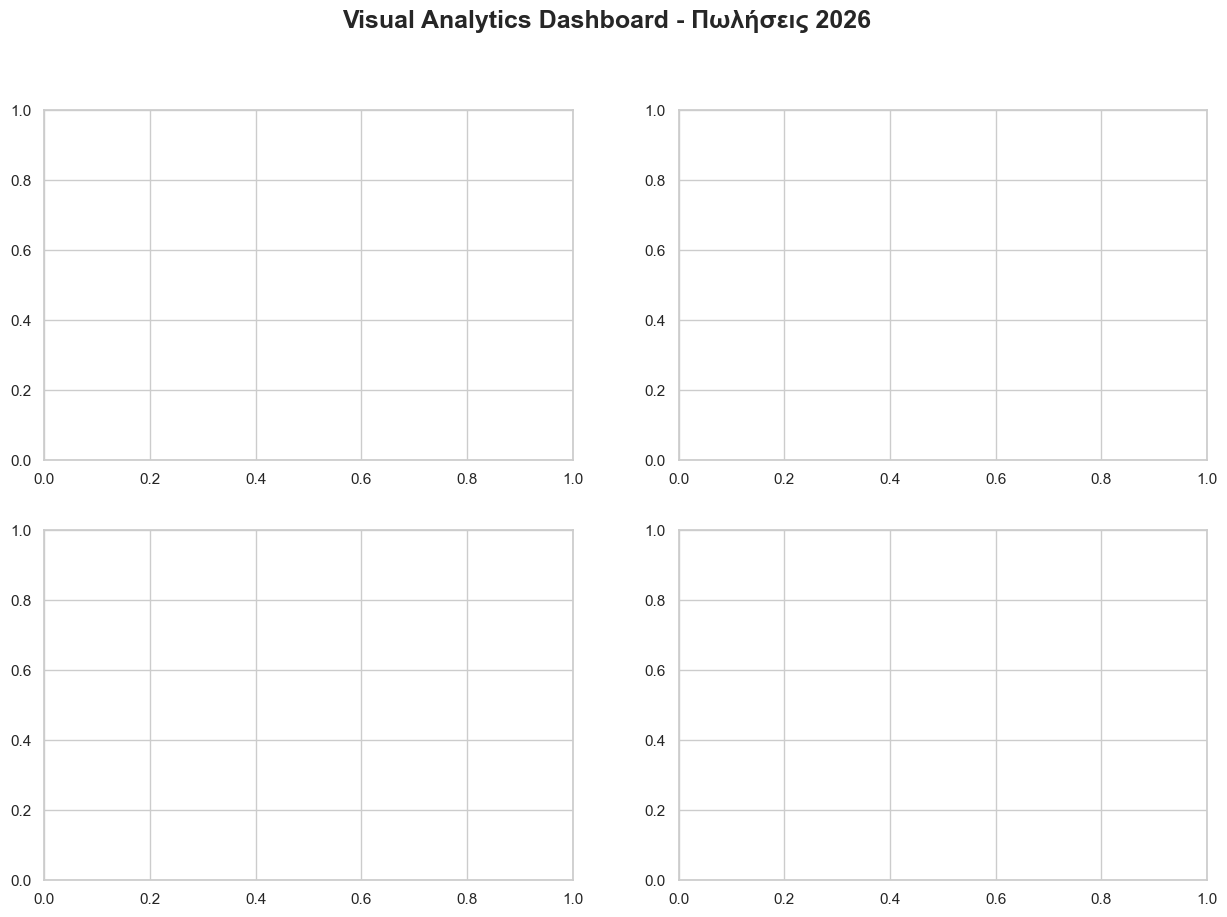

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # 2 σειρές, 2 στήλες διαγραμμάτων
fig.suptitle("Visual Analytics Dashboard - Πωλήσεις 2026", fontsize=18, fontweight='bold', y=0.98)

In [7]:
# --- ΔΙΑΓΡΑΜΜΑ 1: Line Plot (Πάνω Αριστερά) ---
sns.lineplot(ax=axes[0, 0], data=monthly_revenue, x="Μήνας", y="Έσοδα", marker="o", color="navy", linewidth=2.5)
axes[0, 0].set_title("Μηνιαία Τάση Εσόδων", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Συνολικά Έσοδα (€)")

Text(4.444444444444459, 0.5, 'Συνολικά Έσοδα (€)')

In [8]:
# --- ΔΙΑΓΡΑΜΜΑ 2: Bar Plot (Πάνω Δεξιά) ---
sns.barplot(ax=axes[0, 1], data=df_dashboard, x="Κατηγορία", y="Έσοδα", estimator=sum, palette="Blues_d", hue="Κατηγορία", legend=False)
axes[0, 1].set_title("Συνολικά Έσοδα ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 3: Box Plot (Κάτω Αριστερά) ---
sns.boxplot(ax=axes[1, 0], data=df_dashboard, x="Κατηγορία", y="Έσοδα", palette="Set2", hue="Κατηγορία", legend=False)
axes[1, 0].set_title("Κατανομή Εσόδων & Outliers ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 4: Histogram (Κάτω Δεξιά) ---
sns.histplot(ax=axes[1, 1], data=df_dashboard, x="Έσοδα", bins=20, kde=True, color="teal")
axes[1, 1].set_title("Κατανομή Συχνότητας Τιμών Παραγγελίας", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Έσοδα (€)")
axes[1, 1].set_ylabel("Πλήθος Παραγγελιών")

# Βελτιστοποίηση αποστάσεων μεταξύ των διαγραμμάτων
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 4. ΑΠΟΘΗΚΕΥΣΗ ΤΟΥ DASHBOARD
plt.savefig("sales_dashboard_2026.png", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>

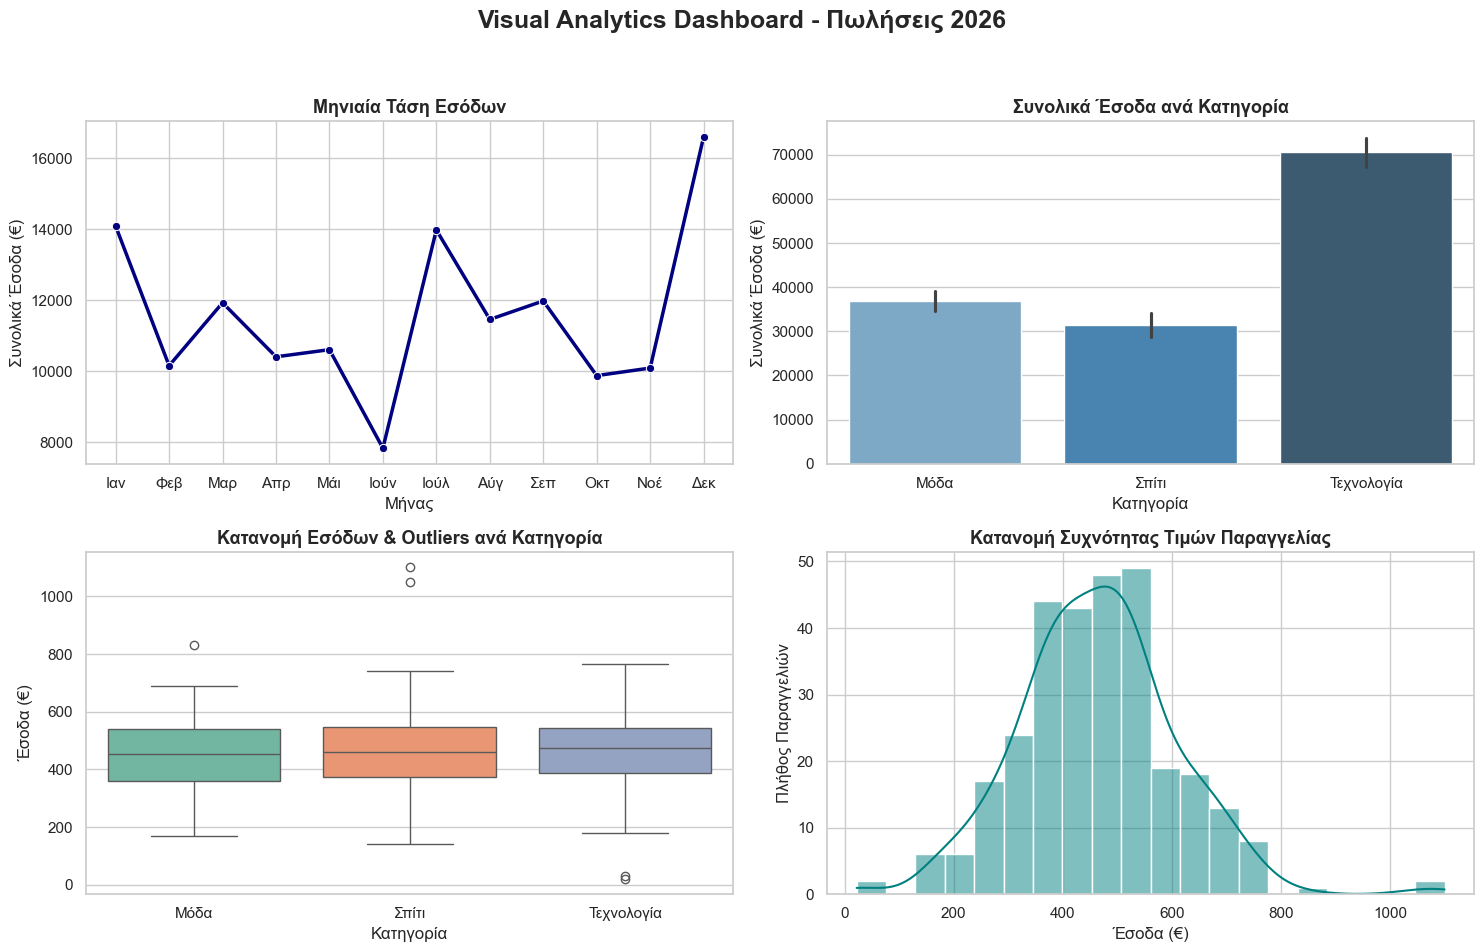

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ΔΗΜΙΟΥΡΓΙΑ DATASET
np.random.seed(42)
n = 300

months_list = ["Ιαν", "Φεβ", "Μαρ", "Απρ", "Μάι", "Ιούν", "Ιούλ", "Αύγ", "Σεπ", "Οκτ", "Νοέ", "Δεκ"]

df_dashboard = pd.DataFrame({
    "Μήνας": np.random.choice(months_list, size=n),
    "Κατηγορία": np.random.choice(["Τεχνολογία", "Μόδα", "Σπίτι"], size=n, p=[0.5, 0.3, 0.2]),
    "Έσοδα": np.random.normal(loc=450, scale=120, size=n).round(2)
})

# Προσθήκη μερικών outliers
df_dashboard.loc[12, "Έσοδα"] = 1100.00
df_dashboard.loc[85, "Έσοδα"] = 1050.00

# 2. ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟ LINE PLOT
# Ταξινομούμε τους μήνες σωστά ημερολογιακά
df_dashboard['Μήνας'] = pd.Categorical(df_dashboard['Μήνας'], categories=months_list, ordered=True)
monthly_revenue = df_dashboard.groupby('Μήνας', observed=False)['Έσοδα'].sum().reset_index()

# 3. ΣΤΗΣΙΜΟ DASHBOARD (2x2 Subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # 2 σειρές, 2 στήλες διαγραμμάτων
fig.suptitle("Visual Analytics Dashboard - Πωλήσεις 2026", fontsize=18, fontweight='bold', y=0.98)

# --- ΔΙΑΓΡΑΜΜΑ 1: Line Plot (Πάνω Αριστερά) ---
sns.lineplot(ax=axes[0, 0], data=monthly_revenue, x="Μήνας", y="Έσοδα", marker="o", color="navy", linewidth=2.5)
axes[0, 0].set_title("Μηνιαία Τάση Εσόδων", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 2: Bar Plot (Πάνω Δεξιά) ---
sns.barplot(ax=axes[0, 1], data=df_dashboard, x="Κατηγορία", y="Έσοδα", estimator=sum, palette="Blues_d", hue="Κατηγορία", legend=False)
axes[0, 1].set_title("Συνολικά Έσοδα ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Συνολικά Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 3: Box Plot (Κάτω Αριστερά) ---
sns.boxplot(ax=axes[1, 0], data=df_dashboard, x="Κατηγορία", y="Έσοδα", palette="Set2", hue="Κατηγορία", legend=False)
axes[1, 0].set_title("Κατανομή Εσόδων & Outliers ανά Κατηγορία", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Έσοδα (€)")

# --- ΔΙΑΓΡΑΜΜΑ 4: Histogram (Κάτω Δεξιά) ---
sns.histplot(ax=axes[1, 1], data=df_dashboard, x="Έσοδα", bins=20, kde=True, color="teal")
axes[1, 1].set_title("Κατανομή Συχνότητας Τιμών Παραγγελίας", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Έσοδα (€)")
axes[1, 1].set_ylabel("Πλήθος Παραγγελιών")

# Βελτιστοποίηση αποστάσεων μεταξύ των διαγραμμάτων
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 4. ΑΠΟΘΗΚΕΥΣΗ ΤΟΥ DASHBOARD
plt.savefig("sales_dashboard_2026.png", dpi=300)

plt.show()